# Brain Tumor MRI Multi-Class Classification

**Goal:** classify MRI images into `glioma`, `meningioma`, `pituitary`, and `no_tumor` using a custom CNN and transfer learning.

This notebook follows the supplied project brief: dataset understanding, preprocessing, augmentation, custom CNN, pretrained models, model evaluation/comparison, explainability/error analysis, and deployment preparation. The supplied dataset contains **2,443 images**: 1,695 train, 502 validation, and 246 test images, across four classes.

## GitHub link: https://github.com/rahulg2527-source/Brain-Tumor-MRI-Multi-Class-Classification.git

## Important medical-use note
This is an educational/research image-classification project, not a clinical diagnostic system. Model confidence is not equivalent to medical certainty. Any real clinical use would require independent clinical validation, appropriate patient-level splitting, bias analysis, regulatory review, and clinician oversight.

In [1]:
# Install only if your Kaggle environment needs these packages.
# TensorFlow is usually preinstalled on Kaggle.
# !pip install -q tensorflow scikit-learn seaborn

In [2]:
import os, zipfile, random, warnings, json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing import image

from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score
)

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: []


2026-09-30 08:05:36.888398: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 1. Locate the dataset
The notebook works both with the uploaded ZIP and with an already-extracted Kaggle dataset. On Kaggle, change `DATASET_ROOT` if your dataset is attached under a different path.

In [3]:
# Auto-detect common locations.
possible_roots = [
    Path('/kaggle/input/datasets/sonug2527/dataset'),
    Path('/kaggle/input/datasets/sonug2527/dataset/Tumour')
]

zip_candidates = []
for root in possible_roots:
    if root.exists():
        zip_candidates.extend(root.rglob('Tumour*.zip'))

DATASET_ROOT = None

# Prefer an already extracted folder containing train/valid/test.
for root in possible_roots:
    if root.exists():
        for p in root.rglob('train'):
            if (p.parent / 'valid').exists() and (p.parent / 'test').exists():
                DATASET_ROOT = p.parent
                break
    if DATASET_ROOT:
        break

if DATASET_ROOT is None and zip_candidates:
    zip_path = zip_candidates[0]
    extract_root = Path('/kaggle/input/datasets/sonug2527/dataset') if Path('/kaggle').exists() else Path('/mnt/data/tumour_data')
    extract_root.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_root)
    DATASET_ROOT = extract_root / 'Tumour'

print('DATASET_ROOT =', DATASET_ROOT)
assert DATASET_ROOT is not None, 'Dataset not found. Attach the ZIP/dataset in Kaggle and update DATASET_ROOT.'
print('Train:', DATASET_ROOT/'train')
print('Valid:', DATASET_ROOT/'valid')
print('Test :', DATASET_ROOT/'test')

DATASET_ROOT = /kaggle/input/datasets/sonug2527/dataset/Tumour
Train: /kaggle/input/datasets/sonug2527/dataset/Tumour/train
Valid: /kaggle/input/datasets/sonug2527/dataset/Tumour/valid
Test : /kaggle/input/datasets/sonug2527/dataset/Tumour/test


In [4]:
CLASS_NAMES = ['glioma', 'meningioma', 'pituitary', 'no_tumor']
SPLITS = ['train', 'valid', 'test']
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

def count_images(split):
    counts = {}
    for cls in CLASS_NAMES:
        folder = DATASET_ROOT / split / cls
        counts[cls] = sum(1 for p in folder.rglob('*') if p.suffix.lower() in IMAGE_EXTS) if folder.exists() else 0
    return counts

counts_df = pd.DataFrame({s: count_images(s) for s in SPLITS}).T
counts_df['Total'] = counts_df.sum(axis=1)
display(counts_df)

,glioma,meningioma,pituitary,no_tumor,Total
train,564,358,438,335,1695
valid,161,124,118,99,502
test,80,63,54,49,246


## 2. Dataset EDA

<Figure size 1000x500 with 0 Axes>

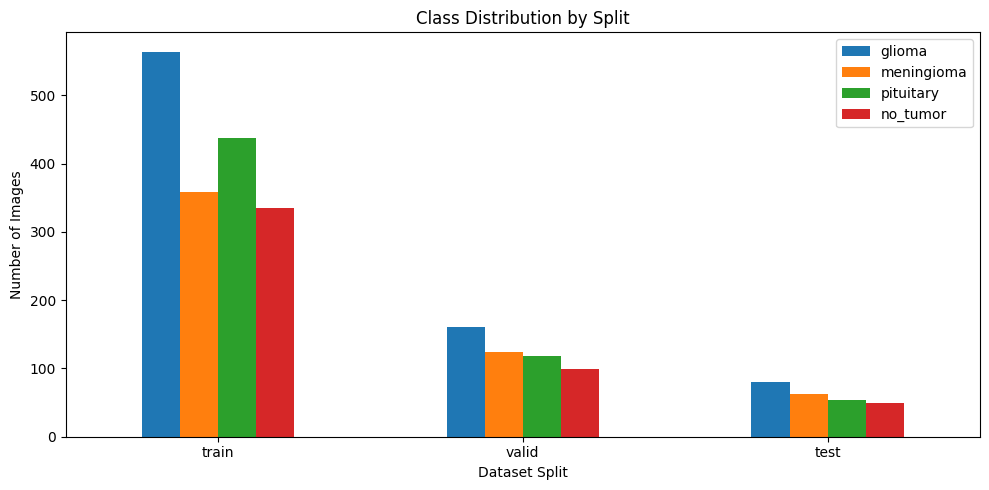

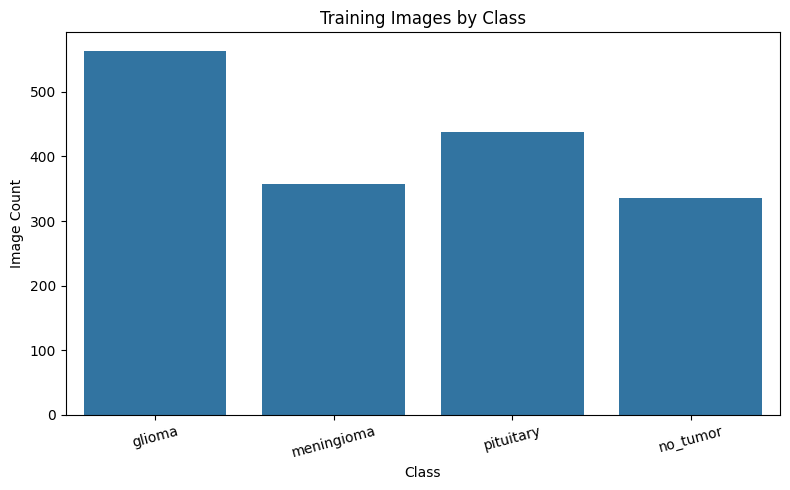

In [5]:
plt.figure(figsize=(10,5))
counts_df[CLASS_NAMES].plot(kind='bar', figsize=(10,5))
plt.title('Class Distribution by Split')
plt.xlabel('Dataset Split')
plt.ylabel('Number of Images')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x=CLASS_NAMES, y=counts_df.loc['train', CLASS_NAMES].values)
plt.title('Training Images by Class')
plt.ylabel('Image Count')
plt.xlabel('Class')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [6]:
def collect_paths(split):
    rows=[]
    for label, cls in enumerate(CLASS_NAMES):
        folder=DATASET_ROOT/split/cls
        for p in folder.rglob('*'):
            if p.suffix.lower() in IMAGE_EXTS:
                rows.append((str(p), cls, label))
    return pd.DataFrame(rows, columns=['path','class','label'])

train_df=collect_paths('train')
valid_df=collect_paths('valid')
test_df=collect_paths('test')

display(train_df.head())
print('Total:', len(train_df), len(valid_df), len(test_df))

,path,class,label
0,/kaggle/input/datasets/sonug2527/dataset/Tumou...,glioma,0
1,/kaggle/input/datasets/sonug2527/dataset/Tumou...,glioma,0
2,/kaggle/input/datasets/sonug2527/dataset/Tumou...,glioma,0
3,/kaggle/input/datasets/sonug2527/dataset/Tumou...,glioma,0
4,/kaggle/input/datasets/sonug2527/dataset/Tumou...,glioma,0


Total: 1695 502 246


        width  height mode
count   500.0   500.0  500
unique    NaN     NaN    1
top       NaN     NaN  RGB
freq      NaN     NaN  500
mean    640.0   640.0  NaN
std       0.0     0.0  NaN
min     640.0   640.0  NaN
25%     640.0   640.0  NaN
50%     640.0   640.0  NaN
75%     640.0   640.0  NaN
max     640.0   640.0  NaN


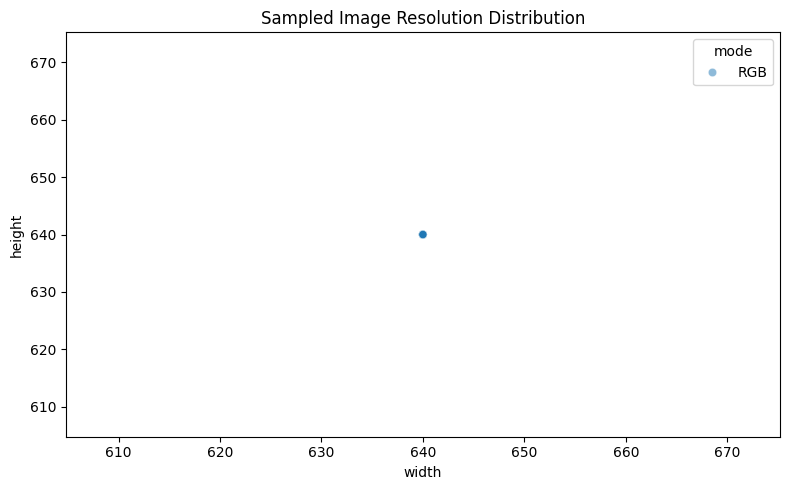

In [7]:
# Inspect image dimensions and channels on a sample.
from PIL import Image
sample_df = train_df.sample(min(500, len(train_df)), random_state=SEED)
size_rows=[]
for p in sample_df.path:
    try:
        with Image.open(p) as im:
            size_rows.append((im.width, im.height, im.mode))
    except Exception:
        pass
size_df=pd.DataFrame(size_rows, columns=['width','height','mode'])
print(size_df.describe(include='all'))

plt.figure(figsize=(8,5))
sns.scatterplot(data=size_df, x='width', y='height', hue='mode', alpha=.5)
plt.title('Sampled Image Resolution Distribution')
plt.tight_layout()
plt.show()

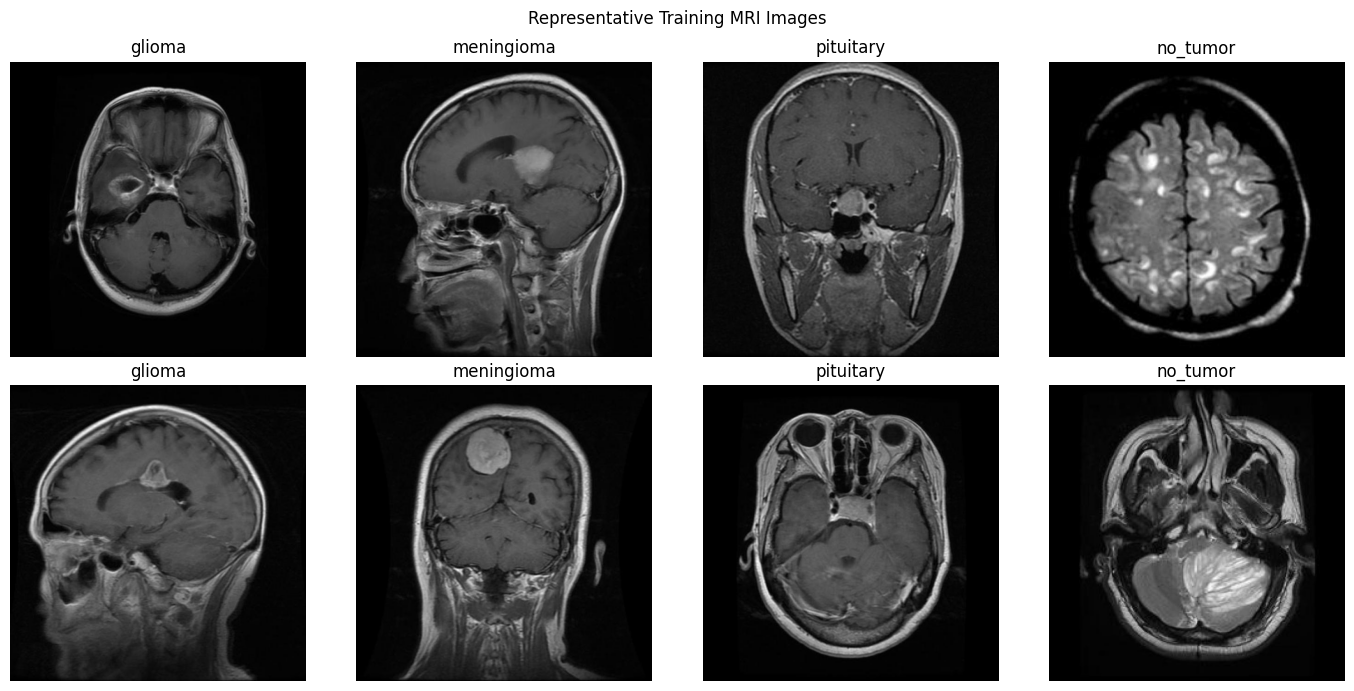

In [8]:
# Show representative MRI images from every class.
fig, axes = plt.subplots(2, 4, figsize=(14,7))
for col, cls in enumerate(CLASS_NAMES):
    subset=train_df[train_df['class']==cls].sample(2, random_state=SEED)
    for row, (_, r) in enumerate(subset.iterrows()):
        img=plt.imread(r['path'])
        axes[row,col].imshow(img, cmap='gray' if img.ndim==2 else None)
        axes[row,col].set_title(cls)
        axes[row,col].axis('off')
plt.suptitle('Representative Training MRI Images')
plt.tight_layout()
plt.show()

## 3. Preprocessing and augmentation
Images are resized to 224×224 and normalized to [0, 1]. Augmentation is applied only to the training pipeline.

Found 1695 files belonging to 4 classes.
Found 502 files belonging to 4 classes.
Found 246 files belonging to 4 classes.


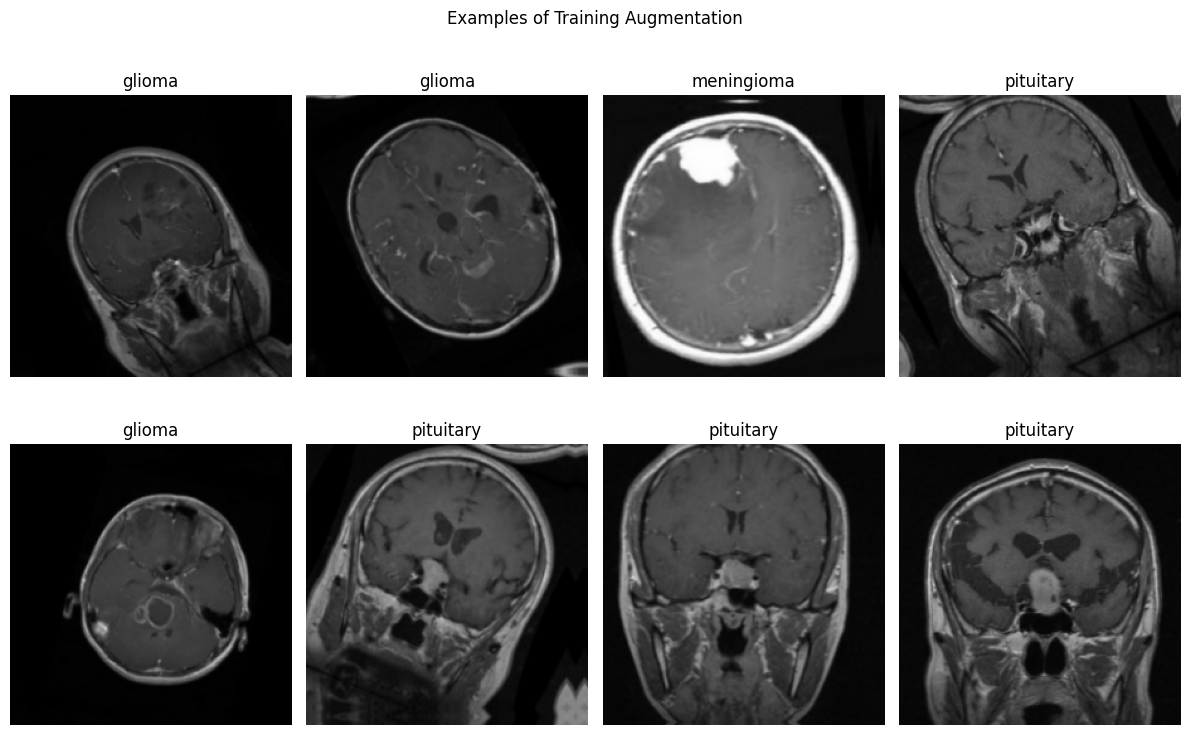

In [9]:
IMG_SIZE=(224,224)
BATCH_SIZE=32
AUTOTUNE=tf.data.AUTOTUNE

train_ds=tf.keras.utils.image_dataset_from_directory(
    DATASET_ROOT/'train', labels='inferred', label_mode='int',
    class_names=CLASS_NAMES, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    shuffle=True, seed=SEED
)
valid_ds=tf.keras.utils.image_dataset_from_directory(
    DATASET_ROOT/'valid', labels='inferred', label_mode='int',
    class_names=CLASS_NAMES, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    shuffle=False
)
test_ds=tf.keras.utils.image_dataset_from_directory(
    DATASET_ROOT/'test', labels='inferred', label_mode='int',
    class_names=CLASS_NAMES, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    shuffle=False
)

augmentation=keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05,0.05)
], name='augmentation')

normalizer=layers.Rescaling(1./255)

train_ds=train_ds.prefetch(AUTOTUNE)
valid_ds=valid_ds.prefetch(AUTOTUNE)
test_ds=test_ds.prefetch(AUTOTUNE)

# Visualize augmentation.
for imgs, labels in train_ds.take(1):
    plt.figure(figsize=(12,8))
    for i in range(8):
        ax=plt.subplot(2,4,i+1)
        aug=augmentation(imgs[i:i+1], training=True)[0]
        plt.imshow(aug.numpy().astype('uint8'))
        plt.title(CLASS_NAMES[int(labels[i])])
        plt.axis('off')
    plt.suptitle('Examples of Training Augmentation')
    plt.tight_layout()
    plt.show()

## 4. Custom CNN

In [10]:
def build_custom_cnn():
    inputs=keras.Input(shape=(*IMG_SIZE,3))
    x=normalizer(inputs)
    x=augmentation(x)
    for filters in [32,64,128,256]:
        x=layers.Conv2D(filters,3,padding='same',activation=None)(x)
        x=layers.BatchNormalization()(x)
        x=layers.ReLU()(x)
        x=layers.MaxPooling2D()(x)
    x=layers.GlobalAveragePooling2D()(x)
    x=layers.Dense(256,activation='relu')(x)
    x=layers.Dropout(0.4)(x)
    outputs=layers.Dense(len(CLASS_NAMES),activation='softmax')(x)
    return keras.Model(inputs,outputs,name='Custom_CNN')

custom_cnn=build_custom_cnn()
custom_cnn.compile(optimizer=keras.optimizers.Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
custom_cnn.summary()

Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 457,156 (1.74 MB)

 Trainable params: 456,196 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [11]:
OUTPUT_DIR=Path('/kaggle/working/brain_tumor_models') if Path('/kaggle').exists() else Path('/mnt/data/brain_tumor_models')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def train_model(model, name, epochs=20):
    path=OUTPUT_DIR/f'{name}.keras'
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=.3, patience=2, min_lr=1e-7, verbose=1),
        ModelCheckpoint(path, monitor='val_loss', save_best_only=True, verbose=1)
    ]
    history=model.fit(train_ds, validation_data=valid_ds, epochs=epochs, callbacks=callbacks)
    return history, path



In [12]:
def plot_history(history, title):
    h=pd.DataFrame(history.history)
    fig,ax=plt.subplots(1,2,figsize=(14,5))
    ax[0].plot(h['accuracy'],label='Train')
    ax[0].plot(h['val_accuracy'],label='Validation')
    ax[0].set_title(f'{title} Accuracy'); ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Accuracy'); ax[0].legend()
    ax[1].plot(h['loss'],label='Train')
    ax[1].plot(h['val_loss'],label='Validation')
    ax[1].set_title(f'{title} Loss'); ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Loss'); ax[1].legend()
    plt.tight_layout(); plt.show()

# plot_history(custom_history, 'Custom CNN')

## 5. Transfer learning models
The project brief suggests pretrained CNNs such as ResNet50, MobileNetV2, InceptionV3 and EfficientNetB0. This notebook implements three practical choices: MobileNetV2, ResNet50 and EfficientNetB0.

In [13]:
def build_transfer_model(name):
    inputs=keras.Input(shape=(*IMG_SIZE,3))
    x=inputs
    if name=='MobileNetV2':
        base=tf.keras.applications.MobileNetV2(include_top=False, weights='imagenet', input_shape=(*IMG_SIZE,3))
        preprocess=tf.keras.applications.mobilenet_v2.preprocess_input
    elif name=='ResNet50':
        base=tf.keras.applications.ResNet50(include_top=False, weights='imagenet', input_shape=(*IMG_SIZE,3))
        preprocess=tf.keras.applications.resnet50.preprocess_input
    elif name=='EfficientNetB0':
        base=tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet', input_shape=(*IMG_SIZE,3))
        preprocess=lambda z: z  # EfficientNet includes input rescaling in current Keras
    else:
        raise ValueError(name)
    base.trainable=False
    x=augmentation(x)
    x=preprocess(x)
    x=base(x, training=False)
    x=layers.GlobalAveragePooling2D()(x)
    x=layers.Dropout(0.35)(x)
    x=layers.Dense(128,activation='relu')(x)
    x=layers.Dropout(0.25)(x)
    outputs=layers.Dense(len(CLASS_NAMES),activation='softmax')(x)
    model=keras.Model(inputs,outputs,name=name)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),loss='sparse_categorical_crossentropy',metrics=['accuracy'])
    return model

# Build all three. Training cells are intentionally separate so you can choose based on GPU/time.
mobilenet=build_transfer_model('MobileNetV2')
resnet=build_transfer_model('ResNet50')
efficientnet=build_transfer_model('EfficientNetB0')
print('Transfer-learning models created.')

Transfer-learning models created.


## 6. Optional fine-tuning
After the classifier head has converged, the top part of the pretrained backbone can be unfrozen and trained at a very small learning rate. Do this only after the frozen-backbone phase.

In [14]:
def fine_tune(model, backbone_name, history_name, epochs=8, unfreeze_last=30):
    base=None
    for layer in model.layers:
        if layer.name.lower().startswith(backbone_name.lower().replace('v2','')):
            pass
    # Safer: find the largest nested Model.
    nested=[l for l in model.layers if isinstance(l, keras.Model)]
    if not nested:
        raise RuntimeError('Backbone model not found')
    base=nested[0]
    base.trainable=True
    for layer in base.layers[:-unfreeze_last]: layer.trainable=False
    model.compile(optimizer=keras.optimizers.Adam(1e-5),loss='sparse_categorical_crossentropy',metrics=['accuracy'])
    return train_model(model, history_name, epochs=epochs)



## 7. Evaluation utilities

In [15]:
def predict_dataset(model, ds):
    probs=model.predict(ds, verbose=0)
    y_true=np.concatenate([y.numpy() for _,y in ds],axis=0)
    y_pred=np.argmax(probs,axis=1)
    return y_true,y_pred,probs

def evaluate_model(model, name):
    y_true,y_pred,probs=predict_dataset(model,test_ds)
    metrics={
        'Model':name,
        'Accuracy':accuracy_score(y_true,y_pred),
        'Precision':precision_score(y_true,y_pred,average='weighted',zero_division=0),
        'Recall':recall_score(y_true,y_pred,average='weighted',zero_division=0),
        'F1':f1_score(y_true,y_pred,average='weighted',zero_division=0)
    }
    print(classification_report(y_true,y_pred,target_names=CLASS_NAMES,zero_division=0))
    cm=confusion_matrix(y_true,y_pred)
    plt.figure(figsize=(7,6))
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES)
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.tight_layout(); plt.show()
    return metrics, y_true,y_pred,probs

## 8. Evaluate trained models
Run the evaluation only for models you have actually trained. The dictionary makes it easy to compare them.

              precision    recall  f1-score   support

      glioma       0.00      0.00      0.00        80
  meningioma       0.00      0.00      0.00        63
   pituitary       0.22      1.00      0.36        54
    no_tumor       0.00      0.00      0.00        49

    accuracy                           0.22       246
   macro avg       0.05      0.25      0.09       246
weighted avg       0.05      0.22      0.08       246



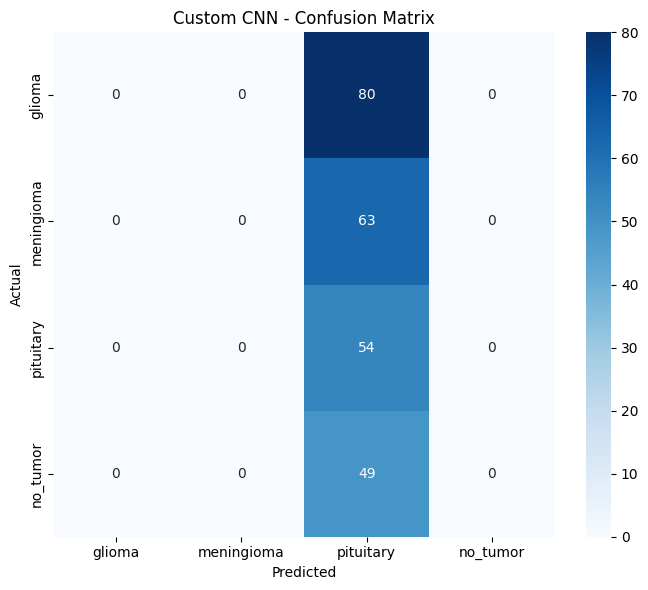

              precision    recall  f1-score   support

      glioma       0.00      0.00      0.00        80
  meningioma       0.00      0.00      0.00        63
   pituitary       0.22      1.00      0.36        54
    no_tumor       0.00      0.00      0.00        49

    accuracy                           0.22       246
   macro avg       0.06      0.25      0.09       246
weighted avg       0.05      0.22      0.08       246



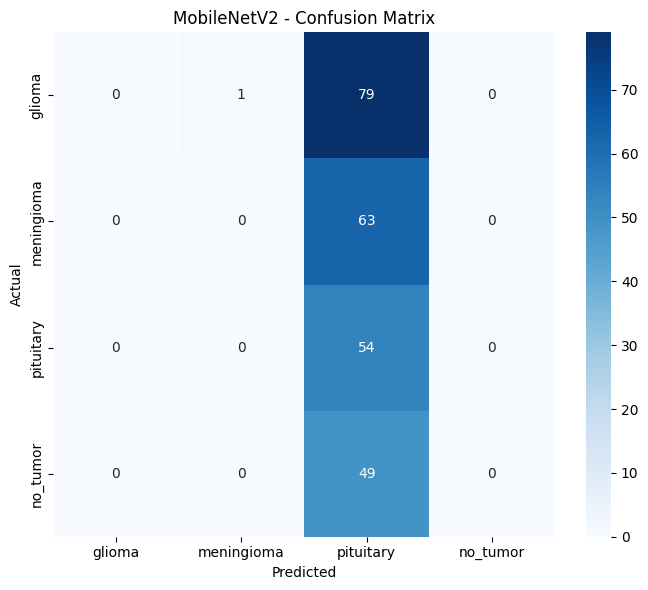

              precision    recall  f1-score   support

      glioma       0.36      0.10      0.16        80
  meningioma       0.23      0.59      0.33        63
   pituitary       0.00      0.00      0.00        54
    no_tumor       0.34      0.22      0.27        49

    accuracy                           0.23       246
   macro avg       0.24      0.23      0.19       246
weighted avg       0.25      0.23      0.19       246



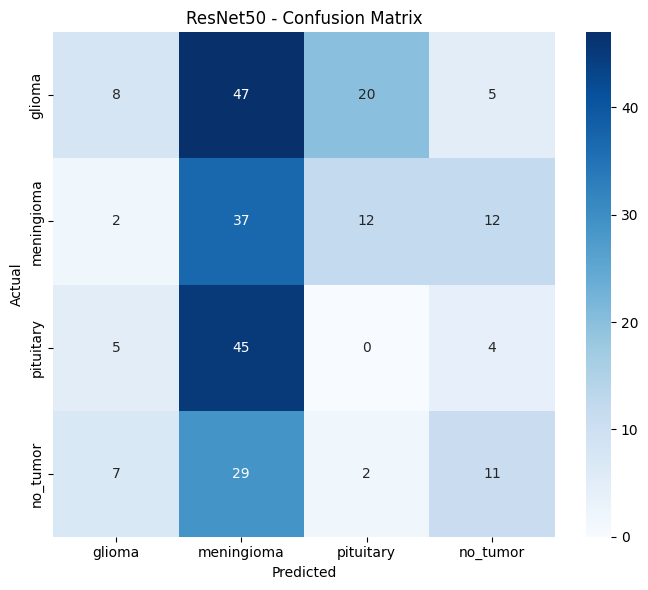

              precision    recall  f1-score   support

      glioma       0.00      0.00      0.00        80
  meningioma       0.33      0.02      0.03        63
   pituitary       0.00      0.00      0.00        54
    no_tumor       0.20      1.00      0.34        49

    accuracy                           0.20       246
   macro avg       0.13      0.25      0.09       246
weighted avg       0.13      0.20      0.08       246



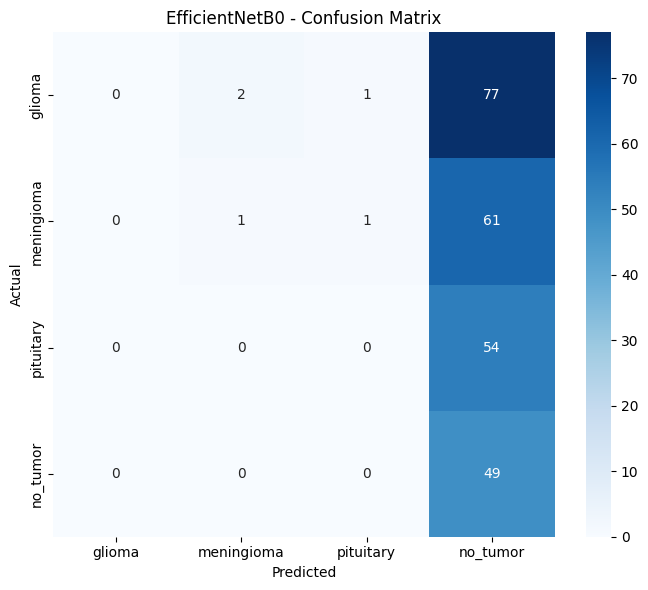

,Model,Accuracy,Precision,Recall,F1
2,ResNet50,0.227642,0.246698,0.227642,0.190865
1,MobileNetV2,0.219512,0.048382,0.219512,0.079289
0,Custom CNN,0.219512,0.048186,0.219512,0.079024
3,EfficientNetB0,0.203252,0.125864,0.203252,0.075072


In [16]:
trained_models = {
    'Custom CNN': custom_cnn,
    'MobileNetV2': mobilenet,
    'ResNet50': resnet,
    'EfficientNetB0': efficientnet,
}
results=[]
predictions={}
for name, model in trained_models.items():
    row, y_true, y_pred, probs = evaluate_model(model, name)
    results.append(row)
    predictions[name]=(y_true,y_pred,probs)
results_df=pd.DataFrame(results).sort_values('F1',ascending=False)
display(results_df)

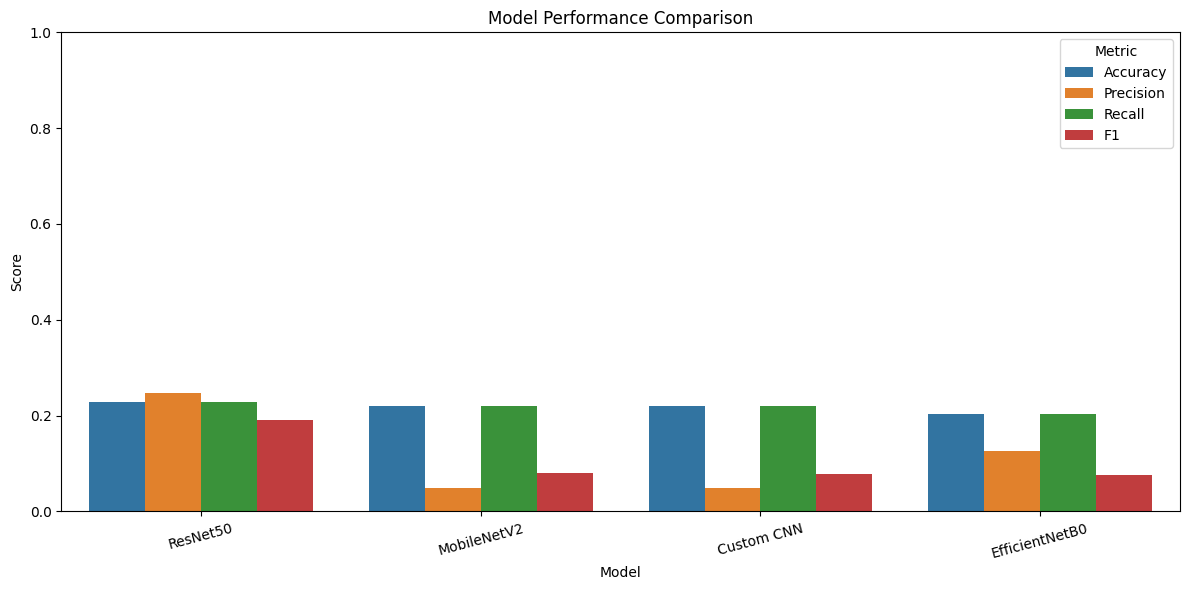

In [17]:
# Model comparison visualization
plot_df=results_df.melt(id_vars='Model',value_vars=['Accuracy','Precision','Recall','F1'],var_name='Metric',value_name='Score')
plt.figure(figsize=(12,6))
sns.barplot(data=plot_df,x='Model',y='Score',hue='Metric')
plt.ylim(0,1); plt.title('Model Performance Comparison'); plt.xticks(rotation=15); plt.tight_layout(); plt.show()

## 9. Error analysis and confidence

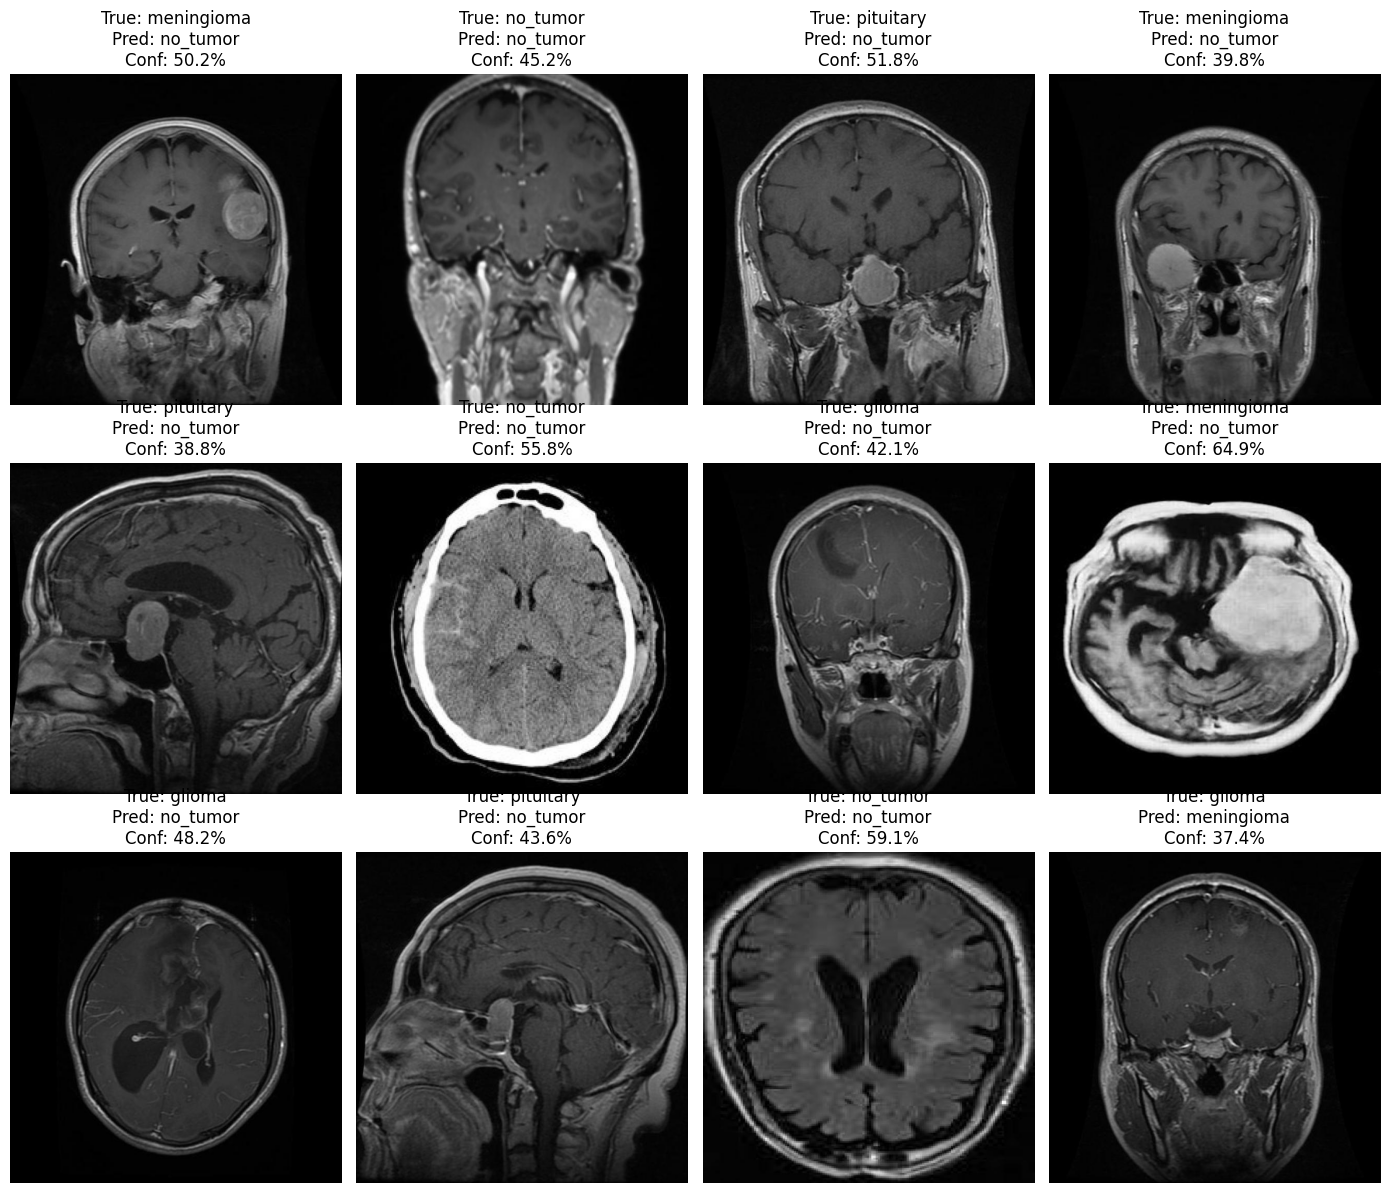

In [18]:
def show_predictions(model, ds, n=12):
    # Get predictions
    y_true, y_pred, probs = predict_dataset(model, ds)

    # Retrieve image paths in deterministic test order
    paths = test_df["path"].tolist()[:len(y_true)]

    # Randomly select images
    rng = np.random.default_rng(SEED)
    idx = rng.choice(
        len(y_true),
        size=min(n, len(y_true)),
        replace=False
    )

    # Create figure
    rows = int(np.ceil(len(idx) / 4))

    fig, axes = plt.subplots(
        rows,
        4,
        figsize=(14, 4 * rows)
    )

    # Make axes 1-dimensional
    axes = np.array(axes).ravel()

    # Display predictions
    for ax, i in zip(axes, idx):

        img = plt.imread(paths[i])

        ax.imshow(
            img,
            cmap="gray" if img.ndim == 2 else None
        )

        correct = y_true[i] == y_pred[i]

        ax.set_title(
            f"True: {CLASS_NAMES[y_true[i]]}\n"
            f"Pred: {CLASS_NAMES[y_pred[i]]}\n"
            f"Conf: {probs[i].max():.1%}"
        )

        ax.axis("off")

    # Hide unused subplots
    for ax in axes[len(idx):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


# Run the function
show_predictions(model, test_ds)

In [19]:
# Find highest-confidence wrong predictions.
y_true,y_pred,probs=predict_dataset(model,test_ds)
errors=np.where(y_true!=y_pred)[0]
if len(errors):
    err_df=pd.DataFrame({
        'path':test_df.iloc[errors]['path'].values,
        'true_class':[CLASS_NAMES[i] for i in y_true[errors]],
        'pred_class':[CLASS_NAMES[i] for i in y_pred[errors]],
        'confidence':probs[errors].max(axis=1)
    }).sort_values('confidence',ascending=False)
    display(err_df.head(20))

,path,true_class,pred_class,confidence
88,/kaggle/input/datasets/sonug2527/dataset/Tumou...,meningioma,no_tumor,0.697986
110,/kaggle/input/datasets/sonug2527/dataset/Tumou...,meningioma,no_tumor,0.694045
98,/kaggle/input/datasets/sonug2527/dataset/Tumou...,meningioma,no_tumor,0.690965
103,/kaggle/input/datasets/sonug2527/dataset/Tumou...,meningioma,no_tumor,0.649210
28,/kaggle/input/datasets/sonug2527/dataset/Tumou...,glioma,no_tumor,0.635519
17,/kaggle/input/datasets/sonug2527/dataset/Tumou...,glioma,no_tumor,0.615989
114,/kaggle/input/datasets/sonug2527/dataset/Tumou...,meningioma,no_tumor,0.576805
6,/kaggle/input/datasets/sonug2527/dataset/Tumou...,glioma,no_tumor,0.576360
119,/kaggle/input/datasets/sonug2527/dataset/Tumou...,meningioma,no_tumor,0.540994
157,/kaggle/input/datasets/sonug2527/dataset/Tumou...,pituitary,no_tumor,0.537081


## 10. Single-image prediction

In [20]:
def predict_image(model, image_path):
    img=tf.keras.utils.load_img(image_path,target_size=IMG_SIZE)
    arr=tf.keras.utils.img_to_array(img)
    probs=model.predict(np.expand_dims(arr,0),verbose=0)[0]
    idx=int(np.argmax(probs))
    plt.figure(figsize=(5,5)); plt.imshow(img); plt.axis('off')
    plt.title(f'{CLASS_NAMES[idx]} | Confidence: {probs[idx]:.2%}')
    plt.show()
    return {'class':CLASS_NAMES[idx], 'confidence':float(probs[idx]), 'probabilities':dict(zip(CLASS_NAMES,probs.astype(float)))}



## 11. Save the selected model

In [21]:
# Set this only after choosing the model you want to deploy.
model.save(OUTPUT_DIR/'best_brain_tumor_model.keras')
print('Saved to:', OUTPUT_DIR/'best_brain_tumor_model.keras')

Saved to: /kaggle/working/brain_tumor_models/best_brain_tumor_model.keras
